# Neural Trajectory Divergence Analysis

This notebook implements analysis for detecting when STOP trial neural trajectories diverge from GO baseline.

**Approach:**
- Test the mean distance in time between the mean neural trajectories

**Session:** fi211115a (to start)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import gammaln
import sys

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

import importlib
import session_class
import cell_analysis
importlib.reload(session_class)
importlib.reload(cell_analysis)

from session_class import Session
from cell_analysis import Cell

print("Imports loaded successfully!")

Imports loaded successfully!


## 1. Load Data and instantiate session

In [19]:
# Load MSN cell database
base_path = Path.cwd().parents[1] / 'data' / 'unified_cell_trial_data'
pickle_file = base_path / 'msn_fiona_cell_trial_data.pkl'
cell_df = pd.read_pickle(pickle_file)

# Select session fi211115a
session_id = 'fi211115a' 
session_id = 'fi211025a'  # Alternative session
session_data = cell_df[cell_df['trial_session'] == session_id]

# Create Session object
session = Session(session_data, verbose=True)

# Drop cells with missing trial type or direction data
session.drop_cells_with_missing_trial_type_or_dir_data()

print(f"\nSession {session_id} loaded successfully!")
print(f"Number of cells after filtering: {session.n_cells}")
print(f"Total cell-trial combinations: {len(session.data)}")

Session fi211115a initialized:
  - Number of cells: 53
  - Total trials: 960
  - Trial types: ['CONT', 'GO', 'STOP']
  - Directions: [np.int64(0), np.int64(180)]

Session fi211115a loaded successfully!
Number of cells after filtering: 53
Total cell-trial combinations: 34395


## 1b. Create Synthetic Dataset for Sanity Check

Creating a controlled dataset with known spike patterns:
- 2 neurons (ID: 1, 2) with identical patterns
- 10 GO left trials
- 2 STOP left trials (SSD2, successful stops)
- All trials successful (trial_failed=False)

In [35]:
def create_synthetic_dataset():
    """
    Create synthetic dataset with controlled spike patterns.
    
    Spike patterns:
    - GO trials: 
        * [-500, 0): spikes every 100ms
        * [0, 200]: spikes every 10ms
        * [200, 500]: spikes every 50ms
        * Saccade at 300ms
    - STOP trials:
        * [-500, 0): spikes every 100ms
        * [0, 150]: spikes every 10ms
        * stop_cue at 108ms
        * [150, 500]: spikes every 20ms
        * No saccade (successful stop)
    """
    
    # Generate spike patterns
    def generate_go_spikes(go_cue_time):
        """Generate spikes for GO trial relative to go_cue."""
        spikes = []
        # Phase 1: [-500, 0) every 100ms
        spikes.extend([go_cue_time + t for t in range(-500, 0, 100)])
        # Phase 2: [0, 200] every 10ms
        spikes.extend([go_cue_time + t for t in range(0, 201, 10)])
        # Phase 3: [200, 500] every 50ms (start at 250 to avoid duplicate at 200)
        spikes.extend([go_cue_time + t for t in range(250, 501, 50)])
        return np.array(sorted(spikes), dtype=float)
    
    def generate_stop_spikes(go_cue_time):
        """Generate spikes for STOP trial relative to go_cue."""
        spikes = []
        # Phase 1: [-500, 0) every 100ms
        spikes.extend([go_cue_time + t for t in range(-500, 0, 100)])
        # Phase 2: [0, 150] every 10ms
        spikes.extend([go_cue_time + t for t in range(0, 151, 10)])
        # Phase 3: [150, 500] every 20ms (start at 170 to avoid duplicate at 150)
        spikes.extend([go_cue_time + t for t in range(170, 501, 20)])
        return np.array(sorted(spikes), dtype=float)
    
    # Create synthetic data
    rows = []
    go_cue_base = 1000.0  # Base timestamp for go_cue
    
    # Create 10 GO trials (trial numbers 1-10)
    for trial_num in range(1, 11):
        go_cue_time = go_cue_base + trial_num * 3000  # Space trials 3s apart
        
        for cell_id in [1, 2]:  # Two neurons
            spikes = generate_go_spikes(go_cue_time)
            saccade_time = go_cue_time + 300
            
            row = {
                'cell_ID': cell_id,
                'cell_type': 'MSN',
                'trial_session': 'synthetic_session',
                'type': 'GO',
                'dir': 180,  # Left
                'ssd_number': np.nan,
                'trial_failed': False,
                'go_cue': go_cue_time,
                'stop_cue': np.nan,
                'first_relevant_saccade': np.array([saccade_time, saccade_time + 50]),
                'reaction_time': 300.0,
                'neural_data': spikes,
                'trial_number': trial_num,
                'trial_length': 2000.0,
                'screen_rotation': 0,
                'saccades': [[saccade_time, saccade_time + 50]],
                'blinks': [],
                'grade': 1,
                'ssd_len': np.nan
            }
            rows.append(row)
    
    # Create 2 STOP trials (trial numbers 11-12)
    for trial_num in range(11, 13):
        go_cue_time = go_cue_base + trial_num * 3000
        stop_cue_time = go_cue_time + 108
        
        for cell_id in [1, 2]:
            spikes = generate_stop_spikes(go_cue_time)
            
            row = {
                'cell_ID': cell_id,
                'cell_type': 'MSN',
                'trial_session': 'synthetic_session',
                'type': 'STOP',
                'dir': 180,  # Left
                'ssd_number': 2,
                'trial_failed': False,  # Successful stop
                'go_cue': go_cue_time,
                'stop_cue': stop_cue_time,
                'first_relevant_saccade': np.array([np.nan, np.nan]),  # No saccade
                'reaction_time': np.nan,
                'neural_data': spikes,
                'trial_number': trial_num,
                'trial_length': 2000.0,
                'screen_rotation': 0,
                'saccades': [],  # No saccade
                'blinks': [],
                'grade': 1,
                'ssd_len': 108.0
            }
            rows.append(row)
    
    # Create DataFrame
    synthetic_df = pd.DataFrame(rows)
    
    print("Synthetic dataset created!")
    print(f"Total rows: {len(synthetic_df)}")
    print(f"Neurons: {sorted(synthetic_df['cell_ID'].unique())}")
    print(f"Trial types: {sorted(synthetic_df['type'].unique())}")
    print(f"Trials per type:")
    print(synthetic_df.groupby('type')['trial_number'].nunique())
    
    # Show spike count statistics
    print(f"\nSpike statistics:")
    for trial_type in ['GO', 'STOP']:
        type_data = synthetic_df[synthetic_df['type'] == trial_type]
        spike_counts = [len(spikes) for spikes in type_data['neural_data']]
        print(f"  {trial_type}: {np.mean(spike_counts):.1f} spikes per trial (all cells)")
    
    return synthetic_df

# Create the synthetic dataset
synthetic_df = create_synthetic_dataset()

# Preview the data
print("\nFirst few rows:")
print(synthetic_df[['cell_ID', 'trial_number', 'type', 'dir', 'trial_failed', 'ssd_number']].head(10))

Synthetic dataset created!
Total rows: 24
Neurons: [np.int64(1), np.int64(2)]
Trial types: ['GO', 'STOP']
Trials per type:
type
GO      10
STOP     2
Name: trial_number, dtype: int64

Spike statistics:
  GO: 32.0 spikes per trial (all cells)
  STOP: 38.0 spikes per trial (all cells)

First few rows:
   cell_ID  trial_number type  dir  trial_failed  ssd_number
0        1             1   GO  180         False         NaN
1        2             1   GO  180         False         NaN
2        1             2   GO  180         False         NaN
3        2             2   GO  180         False         NaN
4        1             3   GO  180         False         NaN
5        2             3   GO  180         False         NaN
6        1             4   GO  180         False         NaN
7        2             4   GO  180         False         NaN
8        1             5   GO  180         False         NaN
9        2             5   GO  180         False         NaN


In [38]:
# Create Session object from synthetic data
synthetic_session = Session(synthetic_df, verbose=True)

print(f"\nSynthetic session created successfully!")
print(f"Number of cells: {synthetic_session.n_cells}")
print(f"Total cell-trial combinations: {len(synthetic_session.data)}")
print(f"Trial types: {sorted(synthetic_session.data['type'].unique())}")
print(f"Direction: {sorted(synthetic_session.data['dir'].unique())}")

# Verify data structure matches real session data
print("\n" + "="*60)
print("DATA STRUCTURE VALIDATION")
print("="*60)
print(f"Columns in synthetic data: {len(synthetic_df.columns)}")
print(f"All expected columns present: {all(col in synthetic_df.columns for col in ['cell_ID', 'type', 'dir', 'neural_data', 'go_cue', 'stop_cue', 'first_relevant_saccade'])}")

# Ready to use with analysis pipeline
print("\n✓ Synthetic dataset ready for analysis pipeline testing!")

Session synthetic_session initialized:
  - Number of cells: 2
  - Total trials: 12
  - Trial types: ['GO', 'STOP']
  - Directions: [np.int64(180)]

Synthetic session created successfully!
Number of cells: 2
Total cell-trial combinations: 24
Trial types: ['GO', 'STOP']
Direction: [np.int64(180)]

DATA STRUCTURE VALIDATION
Columns in synthetic data: 19
All expected columns present: True

✓ Synthetic dataset ready for analysis pipeline testing!


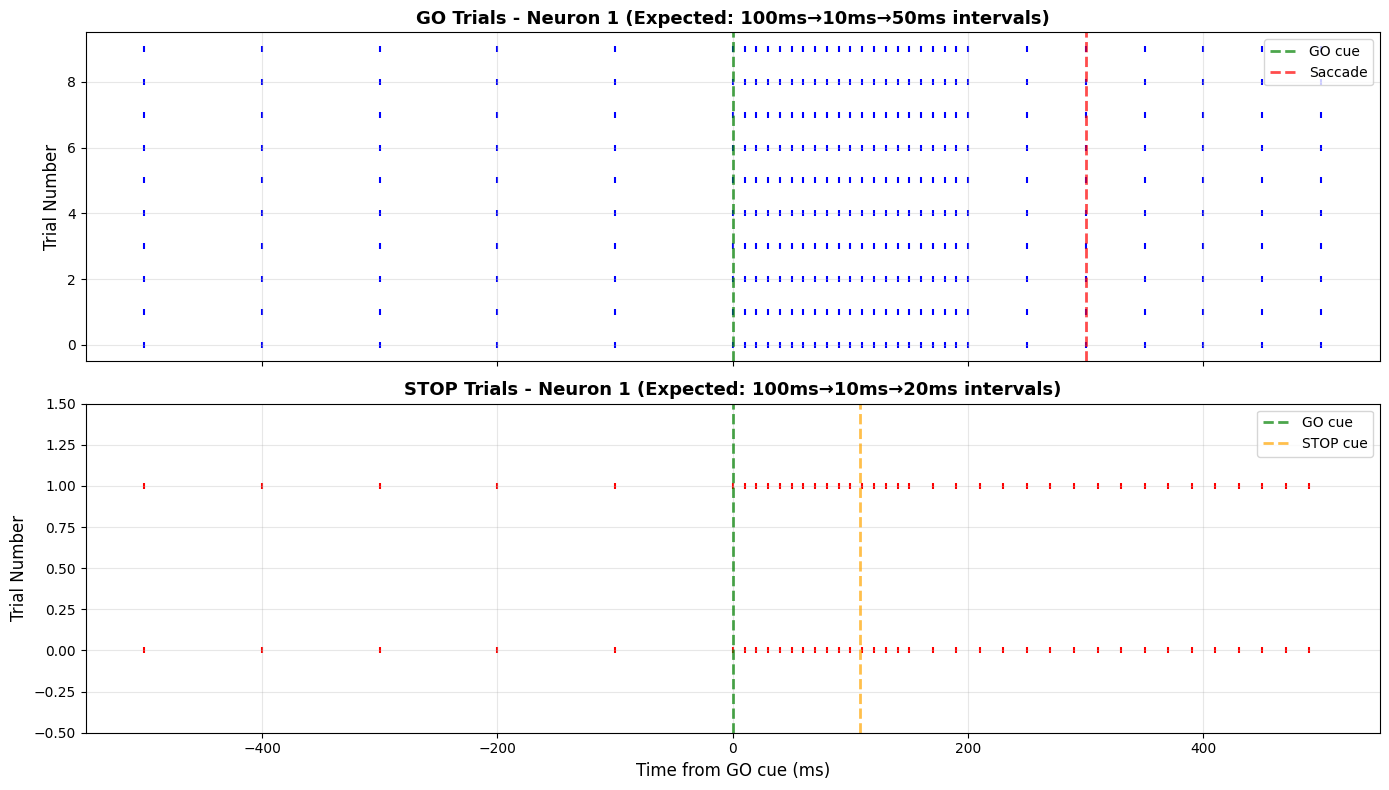


SPIKE TIMING VERIFICATION

First GO trial spikes (aligned to go_cue):
  Pre-GO (-500 to 0): [-500. -400. -300. -200. -100.]
  Early response (0-200): [  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130.
 140. 150. 160. 170. 180. 190. 200.]
  Late response (200-500): [250. 300. 350. 400. 450. 500.]

First STOP trial spikes (aligned to go_cue):
  Pre-GO (-500 to 0): [-500. -400. -300. -200. -100.]
  Early response (0-150): [  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130.
 140. 150.]
  Inhibited response (150-500): [170. 190. 210. 230. 250. 270. 290. 310. 330. 350. 370. 390. 410. 430.
 450. 470. 490.]


In [39]:
# Verify spike patterns by plotting raster for one neuron
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot GO trials
ax_go = axes[0]
cell_1_go = synthetic_df[(synthetic_df['cell_ID'] == 1) & (synthetic_df['type'] == 'GO')]
for idx, (_, row) in enumerate(cell_1_go.iterrows()):
    spikes_aligned = row['neural_data'] - row['go_cue']
    ax_go.scatter(spikes_aligned, [idx] * len(spikes_aligned), s=20, c='blue', marker='|')

ax_go.axvline(0, color='green', linestyle='--', linewidth=2, label='GO cue', alpha=0.7)
ax_go.axvline(300, color='red', linestyle='--', linewidth=2, label='Saccade', alpha=0.7)
ax_go.set_ylabel('Trial Number', fontsize=12)
ax_go.set_title('GO Trials - Neuron 1 (Expected: 100ms→10ms→50ms intervals)', 
                fontsize=13, fontweight='bold')
ax_go.legend(loc='upper right')
ax_go.grid(True, alpha=0.3)
ax_go.set_ylim(-0.5, len(cell_1_go) - 0.5)

# Plot STOP trials
ax_stop = axes[1]
cell_1_stop = synthetic_df[(synthetic_df['cell_ID'] == 1) & (synthetic_df['type'] == 'STOP')]
for idx, (_, row) in enumerate(cell_1_stop.iterrows()):
    spikes_aligned = row['neural_data'] - row['go_cue']
    ax_stop.scatter(spikes_aligned, [idx] * len(spikes_aligned), s=20, c='red', marker='|')

ax_stop.axvline(0, color='green', linestyle='--', linewidth=2, label='GO cue', alpha=0.7)
ax_stop.axvline(108, color='orange', linestyle='--', linewidth=2, label='STOP cue', alpha=0.7)
ax_stop.set_xlabel('Time from GO cue (ms)', fontsize=12)
ax_stop.set_ylabel('Trial Number', fontsize=12)
ax_stop.set_title('STOP Trials - Neuron 1 (Expected: 100ms→10ms→20ms intervals)', 
                  fontsize=13, fontweight='bold')
ax_stop.legend(loc='upper right')
ax_stop.grid(True, alpha=0.3)
ax_stop.set_ylim(-0.5, len(cell_1_stop) - 0.5)

plt.xlim(-550, 550)
plt.tight_layout()
plt.show()

# Print spike timing verification for first GO and first STOP trial
print("\n" + "="*60)
print("SPIKE TIMING VERIFICATION")
print("="*60)

# First GO trial
first_go = synthetic_df[(synthetic_df['cell_ID'] == 1) & (synthetic_df['type'] == 'GO')].iloc[0]
go_spikes_aligned = first_go['neural_data'] - first_go['go_cue']
print(f"\nFirst GO trial spikes (aligned to go_cue):")
print(f"  Pre-GO (-500 to 0): {go_spikes_aligned[go_spikes_aligned < 0]}")
print(f"  Early response (0-200): {go_spikes_aligned[(go_spikes_aligned >= 0) & (go_spikes_aligned <= 200)]}")
print(f"  Late response (200-500): {go_spikes_aligned[go_spikes_aligned > 200]}")

# First STOP trial
first_stop = synthetic_df[(synthetic_df['cell_ID'] == 1) & (synthetic_df['type'] == 'STOP')].iloc[0]
stop_spikes_aligned = first_stop['neural_data'] - first_stop['go_cue']
print(f"\nFirst STOP trial spikes (aligned to go_cue):")
print(f"  Pre-GO (-500 to 0): {stop_spikes_aligned[stop_spikes_aligned < 0]}")
print(f"  Early response (0-150): {stop_spikes_aligned[(stop_spikes_aligned >= 0) & (stop_spikes_aligned <= 150)]}")
print(f"  Inhibited response (150-500): {stop_spikes_aligned[stop_spikes_aligned > 150]}")

In [83]:
# Save synthetic session data to pickle file

# Create filename for synthetic session
synthetic_pickle_file = base_path / 'synthetic_session_data.pkl'
print(synthetic_pickle_file)
# Save the synthetic DataFrame
synthetic_df.to_pickle(synthetic_pickle_file)

print(f"Synthetic session saved to: {synthetic_pickle_file}")
print(f"File size: {synthetic_pickle_file.stat().st_size / 1024:.2f} KB")

# Verify by loading it back
loaded_synthetic_df = pd.read_pickle(synthetic_pickle_file)
print(f"\nVerification:")
print(f"  Original shape: {synthetic_df.shape}")
print(f"  Loaded shape: {loaded_synthetic_df.shape}")
print(f"  Data matches: {synthetic_df.equals(loaded_synthetic_df)}")

/home/barak/Projects/population-analysis/data/unified_cell_trial_data/synthetic_session_data.pkl
Synthetic session saved to: /home/barak/Projects/population-analysis/data/unified_cell_trial_data/synthetic_session_data.pkl
File size: 11.83 KB

Verification:
  Original shape: (24, 19)
  Loaded shape: (24, 19)
  Data matches: True


In [55]:
session = synthetic_session  # Use synthetic session for analysis

## 2. Check Trial Counts

Verify we have enough GO and STOP SSD2 trials for each direction.

In [56]:
# Count successful trials for GO and STOP SSD2 by direction
ssd_num = 2
dir_map = {0: 'Right', 180: 'Left'}

results = []
for direction in [0, 180]:
    dir_name = dir_map[direction]
    
    # GO trials (successful only) - count unique trial numbers
    go_count = len(session.data[
        (session.data['type'] == 'GO') & 
        (session.data['dir'] == direction) &
        (session.data['trial_failed'] == False)
    ].drop_duplicates(subset=['trial_number']))
    results.append({'Direction': dir_name, 'Type': 'GO', 'Trial Count': go_count})
    
    # STOP SSD2 trials (successful only)
    stop_count = len(session.data[
        (session.data['type'] == 'STOP') & 
        (session.data['dir'] == direction) & 
        (session.data['ssd_number'] == ssd_num) &
        (session.data['trial_failed'] == False)
    ].drop_duplicates(subset=['trial_number']))
    results.append({'Direction': dir_name, 'Type': 'STOP SSD2', 'Trial Count': stop_count})

results_df = pd.DataFrame(results)
print("\nSuccessful Trial Counts:")
print("=" * 40)
print(results_df.to_string(index=False))


Successful Trial Counts:
Direction      Type  Trial Count
    Right        GO            0
    Right STOP SSD2            0
     Left        GO           10
     Left STOP SSD2            2


## 3. Spike Binning Function

Bin spikes into 10ms bins over [-50, 300]ms window relative to go_cue.

In [57]:
def bin_spikes_for_trials(session_data, trial_type, direction, ssd_number=None, 
                          success_only=True, epok=[-50, 300], bin_size=10,
                          alignment_point='go_cue', bin_step=None):
    """
    Bin spikes for a set of trials into a matrix.
    
    Parameters:
    -----------
    session_data : pd.DataFrame
        Session data (all cells, all trials)
    trial_type : str
        'GO', 'STOP', or 'CONT'
    direction : int
        0 (right) or 180 (left)
    ssd_number : int, optional
        SSD number (1-4), only for STOP/CONT trials
    success_only : bool
        Include only successful trials
    epok : list
        Time window [start, end] in ms
    bin_size : int
        Bin width in ms
    alignment_point : str
        Event to align to
    bin_step : int, optional
        Step size for sliding window bins in ms. If None, uses non-overlapping bins (step=bin_size).
        For overlapping bins, use bin_step < bin_size (e.g., bin_step=1 for 1ms steps)
    
    Returns:
    --------
    dict : {'counts': (n_trials, n_neurons, n_bins), 'bin_centers': array, 
            'cell_ids': list, 'trial_numbers': list}
    """
    # Filter trials
    mask = (session_data['type'] == trial_type) & (session_data['dir'] == direction)
    if success_only:
        mask &= (session_data['trial_failed'] == False)
    if ssd_number is not None and trial_type in ['STOP', 'CONT']:
        mask &= (session_data['ssd_number'] == ssd_number)
    
    filtered_data = session_data[mask].copy()
    
    if len(filtered_data) == 0:
        return None
    
    # Get unique trials and cells
    trial_numbers = sorted(filtered_data['trial_number'].unique())
    cell_ids = sorted(filtered_data['cell_ID'].unique())
    
    n_trials = len(trial_numbers)
    n_neurons = len(cell_ids)
    
    # Determine bin step
    if bin_step is None:
        bin_step = bin_size  # Non-overlapping bins
    
    # Create sliding window bins
    # Bin timestamps are the right edges (last time of each bin)
    # First bin: (epok[0], epok[0] + bin_size), timestamp = epok[0] + bin_size
    # Last bin: (epok[1] - bin_size, epok[1]), timestamp = epok[1]
    bin_edges_right = np.arange(epok[0] + bin_size, epok[1] + 1, bin_step)
    n_bins = len(bin_edges_right)
    
    # Initialize count matrix: (n_trials, n_neurons, n_bins)
    counts = np.zeros((n_trials, n_neurons, n_bins), dtype=int)
    
    # Bin spikes for each trial and neuron
    for trial_idx, trial_num in enumerate(trial_numbers):
        trial_data = filtered_data[filtered_data['trial_number'] == trial_num]
        
        for neuron_idx, cell_id in enumerate(cell_ids):
            cell_trial = trial_data[trial_data['cell_ID'] == cell_id]
            
            if len(cell_trial) == 0:
                continue
            
            # Get alignment time
            row = cell_trial.iloc[0]
            if alignment_point == 'go_cue':
                t_align = row['go_cue']
            elif alignment_point == 'first_relevant_saccade':
                t_align = row['first_relevant_saccade'][0]
                if pd.isna(t_align):
                    continue
            elif alignment_point == 'stop_cue':
                t_align = row['stop_cue']
                if pd.isna(t_align):
                    continue
            else:
                raise ValueError(f"Unknown alignment point: {alignment_point}")
            
            # Align spikes
            spikes = np.array(row['neural_data'], dtype=float)
            aligned_spikes = spikes - t_align
            
            # Count spikes in each sliding window
            for bin_idx, right_edge in enumerate(bin_edges_right):
                left_edge = right_edge - bin_size
                # Count spikes in [left_edge, right_edge)
                spike_count = np.sum((aligned_spikes >= left_edge) & (aligned_spikes < right_edge))
                counts[trial_idx, neuron_idx, bin_idx] = spike_count
    
    return {
        'counts': counts,
        'bin_centers': bin_edges_right,  # Timestamps are the right edges
        'cell_ids': cell_ids,
        'trial_numbers': trial_numbers,
        'n_trials': n_trials,
        'n_neurons': n_neurons,
        'n_bins': n_bins
    }

print("Binning function defined (with sliding window support)!")

Binning function defined (with sliding window support)!


## 4. Test Binning Function

Let's test the binning on GO trials for one direction.

In [58]:
# Test binning on GO trials, Right direction
test_result = bin_spikes_for_trials(
    session.data, 
    trial_type='GO', 
    direction=0,  # Right
    success_only=True,
    epok=[-50, 300],
    bin_size=10,
    bin_step=5  # 1ms sliding window steps
)

if test_result is not None:
    print("\nBinning test successful!")
    print(f"Shape of count matrix: {test_result['counts'].shape}")
    print(f"  - n_trials: {test_result['n_trials']}")
    print(f"  - n_neurons: {test_result['n_neurons']}")
    print(f"  - n_bins: {test_result['n_bins']}")
    print(f"\nBin timestamps (first 10): {test_result['bin_centers'][:10]}")
    print(f"Bin timestamps (last 10): {test_result['bin_centers'][-10:]}")
    print(f"\nSample spike counts (trial 0, neuron 0, first 20 bins): {test_result['counts'][0, 0, :20]}")
    print(f"Mean spike count per bin (across trials and neurons): {test_result['counts'].mean():.3f}")
else:
    print("No data found for test binning!")

No data found for test binning!


## 5. Neuron Filtering by Firing Rate

Drop neurons with mean firing rate < r_min (default 1 Hz) during the analysis window on GO trials.

In [59]:
def filter_low_firing_neurons(binned_data, r_min=1.0, bin_size=10, epok=[-50, 300]):
    """
    Filter out neurons with mean firing rate below r_min.
    
    Parameters:
    -----------
    binned_data : dict
        Output from bin_spikes_for_trials()
    r_min : float
        Minimum firing rate in Hz (default: 1.0)
    bin_size : int
        Bin size in ms
    epok : list
        Epoch window in ms
    
    Returns:
    --------
    dict : Filtered binned_data with updated counts, cell_ids, n_neurons
          Also includes 'kept_neuron_mask' and 'mean_firing_rates'
    """
    counts = binned_data['counts']  # (n_trials, n_neurons, n_bins)
    n_trials, n_neurons, n_bins = counts.shape
    
    # Calculate mean firing rate for each neuron across all GO trials
    # Sum across trials and bins, divide by (n_trials * total_time_in_sec)
    total_time_sec = (epok[1] - epok[0]) / 1000.0  # Convert ms to sec
    
    # Mean spike count per neuron across all trials and bins
    total_spikes_per_neuron = counts.sum(axis=(0, 2))  # Sum over trials and bins
    mean_fr = total_spikes_per_neuron / (n_trials * total_time_sec)
    
    # Identify neurons to keep
    keep_mask = mean_fr >= r_min
    n_kept = keep_mask.sum()
    n_dropped = n_neurons - n_kept
    
    print(f"\nNeuron filtering (r_min = {r_min} Hz):")
    print(f"  - Original neurons: {n_neurons}")
    print(f"  - Kept neurons: {n_kept}")
    print(f"  - Dropped neurons: {n_dropped}")
    print(f"  - Mean FR range: {mean_fr.min():.2f} - {mean_fr.max():.2f} Hz")
    
    # Filter the data
    filtered_counts = counts[:, keep_mask, :]
    filtered_cell_ids = [binned_data['cell_ids'][i] for i in range(n_neurons) if keep_mask[i]]
    
    return {
        'counts': filtered_counts,
        'bin_centers': binned_data['bin_centers'],
        'bin_size': bin_size,
        'cell_ids': filtered_cell_ids,
        'trial_numbers': binned_data['trial_numbers'],
        'n_trials': binned_data['n_trials'],
        'n_neurons': n_kept,
        'n_bins': binned_data['n_bins'],
        'kept_neuron_mask': keep_mask,
        'mean_firing_rates': mean_fr
    }

print("Neuron filtering function defined!")

Neuron filtering function defined!


## 6. GO Baseline Fitting

Fit Poisson mean trajectory mu_hat[n,t] from GO trials with train/calibration split.

In [60]:
def fit_go_baseline(binned_data, train_fraction=0.7, random_seed=42, eps=1e-6):
    """
    Fit GO baseline model with train/calibration split.
    
    Parameters:
    -----------
    binned_data : dict
        Output from bin_spikes_for_trials() for GO trials
    train_fraction : float
        Fraction of trials for training (default: 0.7)
    random_seed : int
        Random seed for reproducibility
    eps : float
        Small floor value to avoid zeros in mu_hat
    
    Returns:
    --------
    dict : {
        'mu_hat': (n_neurons, n_bins) - mean spike counts per bin,
        'train_indices': trial indices used for training,
        'calib_indices': trial indices used for calibration,
        'train_counts': (n_train_trials, n_neurons, n_bins),
        'calib_counts': (n_calib_trials, n_neurons, n_bins)
    }
    """
    counts = binned_data['counts']  # (n_trials, n_neurons, n_bins)
    n_trials = binned_data['n_trials']
    
    # Split into train and calibration
    np.random.seed(random_seed)
    all_indices = np.arange(n_trials)
    np.random.shuffle(all_indices)
    
    n_train = int(n_trials * train_fraction)
    train_indices = all_indices[:n_train]
    calib_indices = all_indices[n_train:]
    # train_indices = all_indices[16:]
    # calib_indices = all_indices[:17]
    
    train_counts = counts[train_indices]
    calib_counts = counts[calib_indices]
    
    # Fit mu_hat: mean across train trials
    mu_hat = train_counts.mean(axis=0)  # (n_neurons, n_bins)
    mu_hat = mu_hat / ( binned_data['bin_size'] / 1000 )  # Convert to firing rate in Hz
    
    # Apply floor to avoid zeros
    mu_hat = np.maximum(mu_hat, eps)
    
    print(f"\nGO baseline fitting:")
    print(f"  - Total GO trials: {n_trials}")
    print(f"  - Train trials: {len(train_indices)}")
    print(f"  - Calibration trials: {len(calib_indices)}")
    print(f"  - mu_hat shape: {mu_hat.shape}")
    print(f"  - mu_hat range: {mu_hat.min():.6f} - {mu_hat.max():.3f}")
    
    return {
        'mu_hat': mu_hat,
        'train_indices': train_indices,
        'calib_indices': calib_indices,
        'train_counts': train_counts,
        'calib_counts': calib_counts,
        'n_train': len(train_indices),
        'n_calib': len(calib_indices)
    }

print("GO baseline fitting function defined!")

GO baseline fitting function defined!


## 7. Try distance maessure

- Calculte the mean GO trajectory in N-Dim space on a train GO set 
- Create a distance (l2) statistics using a GO train set
- Look at the stop trials

### Set up the data for analysis

In [61]:
def is_go_trial_with_valid_saccade(row, mean_ssd):
    if (row['type'] != 'GO'):
        return True
    if np.isnan(row['first_relevant_saccade']).any():
        return False
    saccade_onset = row['first_relevant_saccade'][0]
    return (saccade_onset - row['go_cue']) > mean_ssd

data = session.data.copy()

stop_trials = data[(data['type'] == 'STOP') & (data['trial_failed'] == False)]
mean_ssd = stop_trials['ssd_len'].mean()
print(f"Mean SSD length for successful STOP trials: {mean_ssd:.2f} ms")

# Filter GO trials
data = data[data.apply(lambda row: is_go_trial_with_valid_saccade(row, mean_ssd), axis=1)]
data.shape

Mean SSD length for successful STOP trials: 108.00 ms


(24, 19)

In [64]:
epok = [-300, 300]
bin_size = 50  # Bin width in ms
bin_step = 10   # Bin step size in ms (sliding windows)
r_min = 1.0    # Hz
direction = 180  # Right

print("=" * 60)
print(f"TESTING PIPELINE: GO trials, Direction={direction} (Right)")
print(f"Sliding window bins: {bin_size}ms width, {bin_step}ms step")
print("=" * 60)

# Step 1: Bin GO trials
go_binned = bin_spikes_for_trials(
    data,
    trial_type='GO',
    direction=direction,
    success_only=True,
    epok=epok,
    bin_size=bin_size,
    bin_step=bin_step
)

# Step 2: Create STOP SSD2 binned data
stop_binned = bin_spikes_for_trials(
    data,
    trial_type='STOP',
    direction=direction,
    ssd_number=2,
    success_only=True,
    epok=epok,
    bin_size=bin_size,
    bin_step=bin_step
)


TESTING PIPELINE: GO trials, Direction=180 (Right)
Sliding window bins: 50ms width, 10ms step


In [65]:
go_binned.keys()

dict_keys(['counts', 'bin_centers', 'cell_ids', 'trial_numbers', 'n_trials', 'n_neurons', 'n_bins'])

In [66]:
stop_binned['counts'].shape
stop_cells = set(stop_binned['cell_ids'])
go_cells = set(go_binned['cell_ids'])
len(stop_cells), len(go_cells)

missing_neurons_set = go_cells.symmetric_difference(stop_cells)
missing_neurons_set


set()

In [73]:
go_binned.keys()
go_binned['counts'].shape
go_binned['bin_centers'].shape

train_fraction=0.7
random_seed=42
n_trials = go_binned['n_trials']
n_train = int(n_trials * train_fraction)

# Split into train and calibration
np.random.seed(random_seed)
all_indices = np.arange(n_trials)
np.random.shuffle(all_indices)

train_indices = all_indices[:n_train]
calib_indices = all_indices[n_train:]

# train_indices = all_indices[16:]
# calib_indices = all_indices[:16]

train_counts = go_binned['counts'][train_indices]
calib_counts = go_binned['counts'][calib_indices]

In [74]:
print(train_counts.shape, calib_counts.shape)

mu_hat = train_counts.mean(axis=0) # (n_neurons, n_bins)
mu_hat.shape


(7, 2, 56) (3, 2, 56)


(2, 56)

In [75]:
# Calculate Euclidean distance from mean at each time point
# calib_counts shape: (78, 53, 350) - 78 trials, 53 neurons, 350 time points
# mu_hat shape: (53, 350) - mean firing rate for 53 neurons, 350 time points

# Compute difference from mean for each trial
diff = calib_counts - mu_hat[np.newaxis, :, :]  # Shape: (78, 53, 350)

# Calculate Euclidean distance at each time point
# Sum squared differences across neurons (axis=1), then take square root
euclidean_distances = np.sqrt((diff ** 2).sum(axis=1))  # Shape: (78, 350)

print(f"Euclidean distances shape: {euclidean_distances.shape}")
print(f"Mean distance across time: {euclidean_distances.mean():.3f}")
print(f"Distance range: {euclidean_distances.min():.3f} - {euclidean_distances.max():.3f}")


Euclidean distances shape: (3, 56)
Mean distance across time: 0.000
Distance range: 0.000 - 0.000


In [76]:
# Fix dimension mismatch by removing missing neurons from GO data (missing in STOP)
for missing_neuron in missing_neurons_set:

    # Find index of the missing neuron in go_binned
    if missing_neuron in go_binned['cell_ids']:
        neuron_idx = go_binned['cell_ids'].index(missing_neuron)
        print(f"Removing neuron {missing_neuron} at index {neuron_idx}")
        
        # Create a mask for all neurons except the missing one
        keep_mask = np.ones(go_binned['n_neurons'], dtype=bool)
        keep_mask[neuron_idx] = False
        
        # Filter go_binned data
        go_binned['counts'] = go_binned['counts'][:, keep_mask, :]
        go_binned['cell_ids'] = [cid for cid in go_binned['cell_ids'] if cid != missing_neuron]
        go_binned['n_neurons'] = go_binned['n_neurons'] - 1
        
        # Also filter mu_hat (already computed)
        mu_hat = mu_hat[keep_mask, :]
        
        print(f"Updated go_binned['counts'] shape: {go_binned['counts'].shape}")
        print(f"Updated go_binned['n_neurons']: {go_binned['n_neurons']}")
        print(f"Updated mu_hat shape: {mu_hat.shape}")
    else:
        print(f"Neuron {missing_neuron} not found in go_binned")

# Verify dimensions now match
print(f"\nDimension check:")
print(f"  GO neurons: {go_binned['n_neurons']}")
print(f"  STOP neurons: {stop_binned['n_neurons']}")
print(f"  Match: {go_binned['n_neurons'] == stop_binned['n_neurons']}")

# Calculate Euclidean distance from GO mean for STOP trials
stop_counts_filtered = stop_binned['counts']

# Compute difference from mean for each STOP trial
diff_stop = stop_counts_filtered - mu_hat[np.newaxis, :, :]  # Should now broadcast correctly

# Calculate Euclidean distance at each time point
euclidean_distances_stop = np.sqrt((diff_stop ** 2).sum(axis=1))

print(f"\nSTOP Euclidean distances shape: {euclidean_distances_stop.shape}")
print(f"Mean distance across time (STOP): {euclidean_distances_stop.mean():.3f}")
print(f"Distance range (STOP): {euclidean_distances_stop.min():.3f} - {euclidean_distances_stop.max():.3f}")

# Compare with GO calibration distances
print(f"\nComparison:")
print(f"GO calibration mean distance: {euclidean_distances.mean():.3f}")
print(f"STOP mean distance: {euclidean_distances_stop.mean():.3f}")
print(f"Difference: {euclidean_distances_stop.mean() - euclidean_distances.mean():.3f}")


Dimension check:
  GO neurons: 2
  STOP neurons: 2
  Match: True

STOP Euclidean distances shape: (2, 56)
Mean distance across time (STOP): 0.530
Distance range (STOP): 0.000 - 4.243

Comparison:
GO calibration mean distance: 0.000
STOP mean distance: 0.530
Difference: 0.530


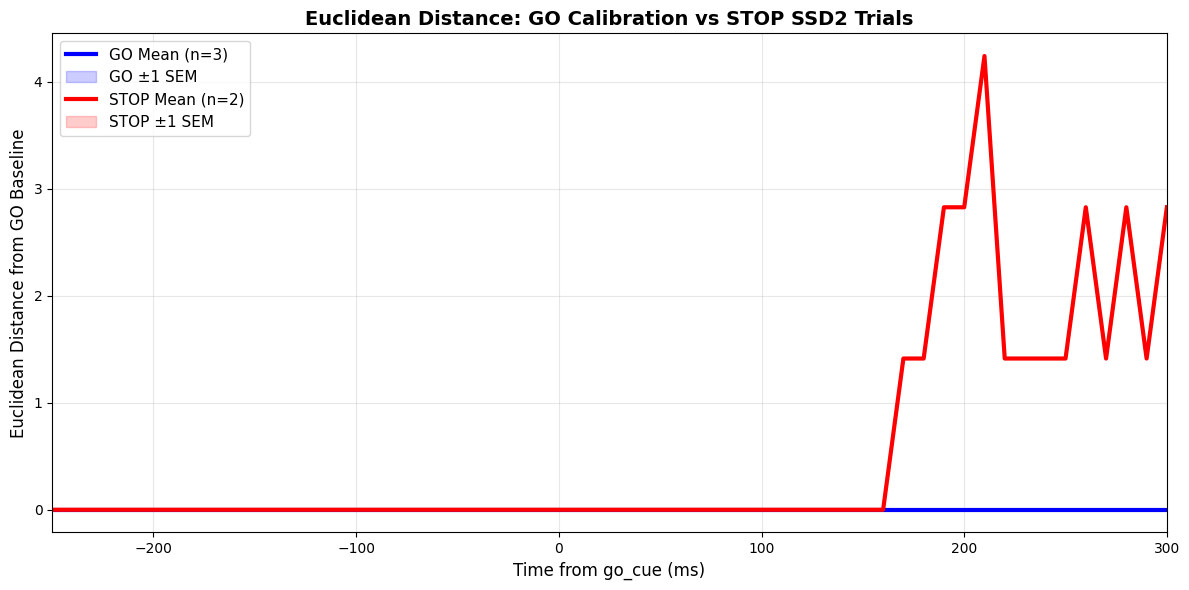


Euclidean Distance Statistics:
  - GO Mean distance (across all time): 0.000
  - GO Distance range (mean): 0.000 - 0.000
  - STOP Mean distance (across all time): 0.530
  - STOP Distance range (mean): 0.000 - 4.243


In [77]:
# Plot Euclidean distances across time with mean and error bars
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot all individual GO calibration trials in light gray
for i in range(euclidean_distances.shape[0]):
        ax.plot(go_binned['bin_centers'], euclidean_distances[i, :], 
                        color='gray', alpha=0.2, linewidth=0.5)

# Compute GO mean and SEM
euclidean_mean = euclidean_distances.mean(axis=0)
euclidean_sem = euclidean_distances.std(axis=0, ddof=1) / np.sqrt(euclidean_distances.shape[0])

# Plot GO mean with error bars
ax.plot(go_binned['bin_centers'], euclidean_mean, 
                color='blue', linewidth=3, label=f'GO Mean (n={euclidean_distances.shape[0]})')
ax.fill_between(go_binned['bin_centers'], 
                                euclidean_mean - euclidean_sem, 
                                euclidean_mean + euclidean_sem,
                                color='blue', alpha=0.2, label='GO ±1 SEM')

# Plot all individual STOP trials in light red
for i in range(euclidean_distances_stop.shape[0]):
        ax.plot(go_binned['bin_centers'][:euclidean_distances_stop.shape[1]], 
                        euclidean_distances_stop[i, :], 
                        color='red', alpha=0.3, linewidth=0.5)

# Compute STOP mean and SEM
euclidean_mean_stop = euclidean_distances_stop.mean(axis=0)
euclidean_sem_stop = euclidean_distances_stop.std(axis=0, ddof=1) / np.sqrt(euclidean_distances_stop.shape[0])

# Plot STOP mean with error bars
ax.plot(go_binned['bin_centers'][:euclidean_distances_stop.shape[1]], 
                euclidean_mean_stop, 
                color='red', linewidth=3, label=f'STOP Mean (n={euclidean_distances_stop.shape[0]})')
ax.fill_between(go_binned['bin_centers'][:euclidean_distances_stop.shape[1]], 
                                euclidean_mean_stop - euclidean_sem_stop, 
                                euclidean_mean_stop + euclidean_sem_stop,
                                color='red', alpha=0.2, label='STOP ±1 SEM')

ax.set_xlabel('Time from go_cue (ms)', fontsize=12)
ax.set_ylabel('Euclidean Distance from GO Baseline', fontsize=12)
ax.set_title('Euclidean Distance: GO Calibration vs STOP SSD2 Trials', 
                         fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(go_binned['bin_centers'][0], go_binned['bin_centers'][-1])

plt.tight_layout()
plt.show()

print(f"\nEuclidean Distance Statistics:")
print(f"  - GO Mean distance (across all time): {euclidean_mean.mean():.3f}")
print(f"  - GO Distance range (mean): {euclidean_mean.min():.3f} - {euclidean_mean.max():.3f}")
print(f"  - STOP Mean distance (across all time): {euclidean_mean_stop.mean():.3f}")
print(f"  - STOP Distance range (mean): {euclidean_mean_stop.min():.3f} - {euclidean_mean_stop.max():.3f}")

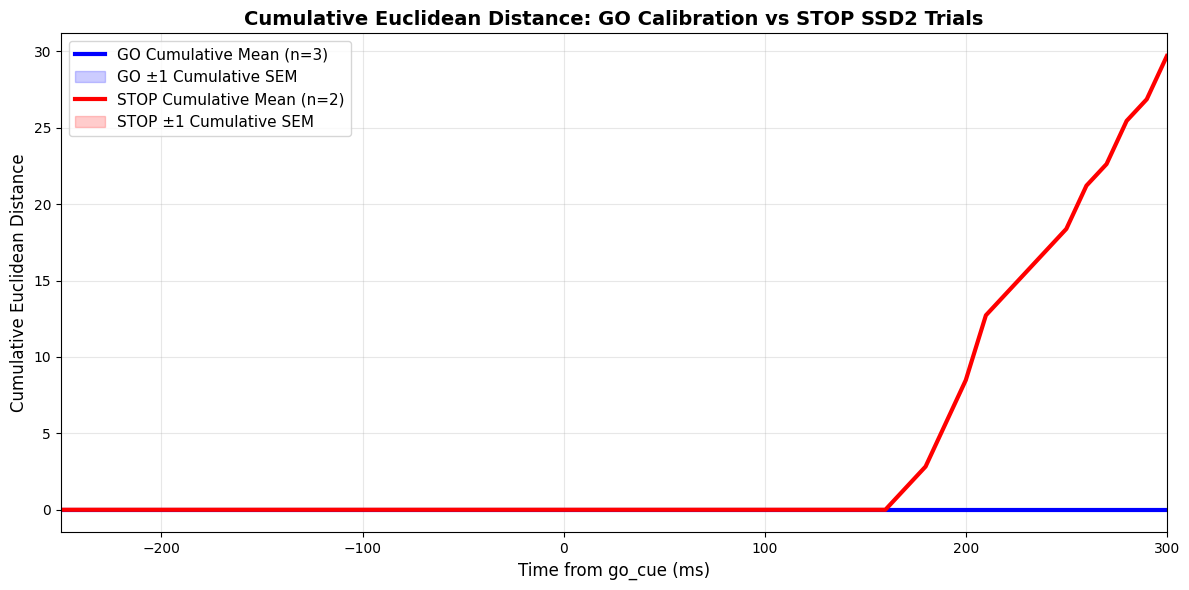


Cumulative Euclidean Distance Statistics:
  - GO Final cumulative distance: 0.0
  - STOP Final cumulative distance: 29.7
  - Difference at final time: 29.7


In [78]:
# Calculate cumulative sum of mean and std for GO and STOP distances
go_cumsum_mean = np.cumsum(euclidean_mean)
go_cumsum_std = np.cumsum(euclidean_sem)

stop_cumsum_mean = np.cumsum(euclidean_mean_stop)
stop_cumsum_std = np.cumsum(euclidean_sem_stop)

# Plot cumulative distances
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot GO cumulative mean with error bars
ax.plot(go_binned['bin_centers'], go_cumsum_mean, 
    color='blue', linewidth=3, label=f'GO Cumulative Mean (n={euclidean_distances.shape[0]})')
ax.fill_between(go_binned['bin_centers'], 
        go_cumsum_mean - go_cumsum_std, 
        go_cumsum_mean + go_cumsum_std,
        color='blue', alpha=0.2, label='GO ±1 Cumulative SEM')

# Plot STOP cumulative mean with error bars
ax.plot(go_binned['bin_centers'][:euclidean_distances_stop.shape[1]], 
    stop_cumsum_mean, 
    color='red', linewidth=3, label=f'STOP Cumulative Mean (n={euclidean_distances_stop.shape[0]})')
ax.fill_between(go_binned['bin_centers'][:euclidean_distances_stop.shape[1]], 
        stop_cumsum_mean - stop_cumsum_std, 
        stop_cumsum_mean + stop_cumsum_std,
        color='red', alpha=0.2, label='STOP ±1 Cumulative SEM')

ax.set_xlabel('Time from go_cue (ms)', fontsize=12)
ax.set_ylabel('Cumulative Euclidean Distance', fontsize=12)
ax.set_title('Cumulative Euclidean Distance: GO Calibration vs STOP SSD2 Trials', 
         fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(go_binned['bin_centers'][0], go_binned['bin_centers'][-1])

plt.tight_layout()
plt.show()

print(f"\nCumulative Euclidean Distance Statistics:")
print(f"  - GO Final cumulative distance: {go_cumsum_mean[-1]:.1f}")
print(f"  - STOP Final cumulative distance: {stop_cumsum_mean[-1]:.1f}")
print(f"  - Difference at final time: {stop_cumsum_mean[-1] - go_cumsum_mean[-1]:.1f}")